In [1]:
import os

import h5py
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

from fit.fit_v7 import Fit
from fit.plot import *

from fit.get_data import *

In [ ]:
from dask.distributed import Client

# Check if a client is already running
try:
    client = Client.current()
    print("Client is already running.")
except:
    # No client is running, so create a new one
    client = Client(
        n_workers=12, threads_per_worker=1
    )  # start distributed scheduler locally.
    print("Started a new client.")

client

c:\Users\bartlinghp\repositories\data-analysis\.venv\Lib\site-packages\distributed\node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 60154 instead
  warnings.warn(


Started a new client.


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:60154/status,
Dashboard: http://127.0.0.1:60154/status,Workers: 12
Total threads: 12,Total memory: 15.69 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:60157,Workers: 0
Dashboard: http://127.0.0.1:60154/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:60239,Total threads: 1
Dashboard: http://127.0.0.1:60242/status,Memory: 1.31 GiB
Nanny: tcp://127.0.0.1:60160,


2025-09-02 15:27:52,932 - distributed.scheduler - WARNING - Worker failed to heartbeat for 1067s; attempting restart: <WorkerState 'tcp://127.0.0.1:60204', name: 6, status: running, memory: 0, processing: 0>
2025-09-02 15:27:52,935 - distributed.scheduler - WARNING - Worker failed to heartbeat for 1067s; attempting restart: <WorkerState 'tcp://127.0.0.1:60205', name: 4, status: running, memory: 0, processing: 0>
2025-09-02 15:27:52,935 - distributed.scheduler - WARNING - Worker failed to heartbeat for 1067s; attempting restart: <WorkerState 'tcp://127.0.0.1:60206', name: 3, status: running, memory: 0, processing: 0>
2025-09-02 15:27:52,937 - distributed.scheduler - WARNING - Worker failed to heartbeat for 1066s; attempting restart: <WorkerState 'tcp://127.0.0.1:60208', name: 11, status: running, memory: 0, processing: 0>
2025-09-02 15:27:52,949 - distributed.scheduler - WARNING - Worker failed to heartbeat for 1066s; attempting restart: <WorkerState 'tcp://127.0.0.1:60209', name: 1, st

In [5]:
folder = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_08_25"
file = r"20250825_094945_esr.h5"

folder = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_02_without"
file = r"20250902_095058_esr.h5"

folder = r"\\tsn.tno.nl\RA-Data\SV\sv-096125\03_Widefield\Data\Stark\2025_09_02_without_sweep"
file = r"20250902_145235_esr.h5"

all_files = os.listdir(folder)
print(all_files)

path = os.path.join(folder, file)
widefield_print_settings(path)

['fit_results', '20250902_145235_esr.h5', '20250902_145235_esr.pdf', '20250902_145504_esr.h5', '20250902_145504_esr.pdf', '20250902_145732_esr.h5', '20250902_145732_esr.pdf', '20250902_145934_esr.h5', '20250902_145934_esr.pdf', '20250902_150201_esr.h5', '20250902_150201_esr.pdf', '20250902_150403_esr.h5', '20250902_150403_esr.pdf', '20250902_150613_esr.h5', '20250902_150613_esr.pdf', '20250902_150825_esr.h5', '20250902_150825_esr.pdf', '20250902_151036_esr.h5', '20250902_151036_esr.pdf', '20250902_151252_esr.h5', '20250902_151252_esr.pdf', '20250902_151500_esr.h5', '20250902_151500_esr.pdf', '20250902_151751_esr.h5', '20250902_151751_esr.pdf', '20250902_151946_esr.h5', '20250902_151946_esr.pdf', '20250902_152142_esr.h5', '20250902_152142_esr.pdf', '20250902_152343_esr.h5', '20250902_152343_esr.pdf', '20250902_152537_esr.h5', '20250902_152537_esr.pdf', '20250902_152738_esr.h5', '20250902_152738_esr.pdf', '20250902_152934_esr.h5', '20250902_152934_esr.pdf', '20250902_153437_esr.h5', '202

In [6]:
%%time
ds_esr, ds_ql, ds_timetrace = widefield_get_data(folder, file, esr_normalized=True, ql_normalized=True)

CPU times: total: 15.6 ms
Wall time: 572 ms


In [7]:
ds_esr

<xarray.DataArray 'esr_normalized' (blocks: 1, y: 50, x: 50, rf: 901)> Size: 18MB
dask.array<open_dataset-esr_normalized, shape=(1, 50, 50, 901), dtype=float64, chunksize=(1, 10, 10, 901), chunktype=numpy.ndarray>
Coordinates:
  * blocks   (blocks) int64 8B 0
  * y        (y) int64 400B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
  * x        (x) int64 400B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
  * rf       (rf) float64 7kB 2.65e+09 2.65e+09 2.651e+09 ... 3.1e+09 3.1e+09

## Analyse quicklook

In [5]:
# inspect quicklook data
ds_ql

<xarray.DataArray 'quicklook_normalized' (ql_blocks: 1, rf: 701)> Size: 6kB
dask.array<open_dataset-quicklook_normalized, shape=(1, 701), dtype=float64, chunksize=(1, 701), chunktype=numpy.ndarray>
Coordinates:
  * ql_blocks  (ql_blocks) int64 8B 0
  * rf         (rf) float64 6kB 2.7e+09 2.7e+09 2.701e+09 ... 3.05e+09 3.05e+09

In [6]:
# sum quicklook data over blocks
ds_ql = ds_ql.sum(dim="ql_blocks")

In [7]:
# ??
ds_ql = ds_esr.isel(x=24, y=0).sum(dim="blocks")

In [8]:
# how to access a coordinate
ds_ql.coords["rf"]

<xarray.DataArray 'rf' (rf: 701)> Size: 6kB
array([2.7000e+09, 2.7005e+09, 2.7010e+09, ..., 3.0490e+09, 3.0495e+09,
       3.0500e+09])
Coordinates:
    y        int64 8B 0
    x        int64 8B 24
  * rf       (rf) float64 6kB 2.7e+09 2.7e+09 2.701e+09 ... 3.05e+09 3.05e+09

In [9]:
fit_obj = Fit(ds_ql, nr_of_dips=8, linewidth=1.0e6, nitrogen=15)
fit_obj.fit_odmr_data_0d()

In [10]:
plot_obj = Plot_ODMR_0D(ds_ql, fit_obj.fit_result, nitrogen=15)

(<Figure size 800x400 with 1 Axes>,
 <Axes: xlabel='freq (Hz)', ylabel='PL (a.u.)'>)

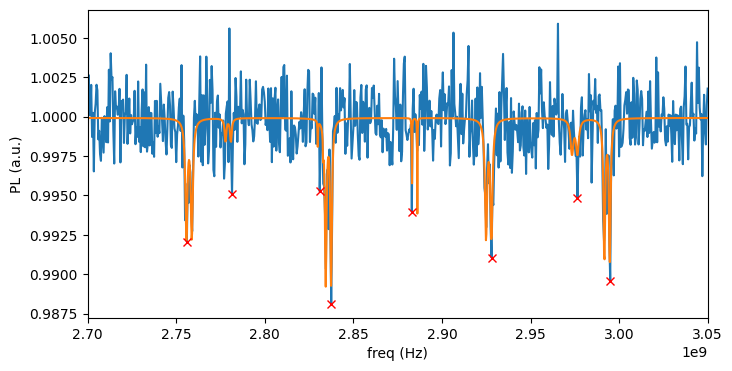

In [11]:
plot_obj.plot_fit()

In [16]:
fit_obj.fit_B_field_0d()

In [17]:
fit_obj.fit_B_result

<xarray.Dataset> Size: 72B
Dimensions:    (zfs_b: 4, zfs_b_err: 4, redchi: 1)
Coordinates:
  * zfs_b      (zfs_b) float64 32B 2.871e+09 -18.53 25.7 -8.859
  * zfs_b_err  (zfs_b_err) float64 32B 0.3561 2.251e-07 2.27e-07 2.252e-07
  * redchi     (redchi) float64 8B 6.868e+10
Data variables:
    *empty*

## Analyse timetrace

In [18]:
%%time
ds_esr, ds_ql, ds_timetrace = widefield_get_data(folder, file, esr_normalized=True, ql_normalized=True)

CPU times: total: 78.1 ms
Wall time: 235 ms


In [19]:
ds_timetrace

<xarray.DataArray 'timetrace' (ql_blocks: 10, y: 50, x: 50)> Size: 200kB
dask.array<open_dataset-timetrace, shape=(10, 50, 50), dtype=float64, chunksize=(1, 10, 10), chunktype=numpy.ndarray>
Coordinates:
  * ql_blocks  (ql_blocks) int64 80B 0 1 2 3 4 5 6 7 8 9
  * y          (y) int64 400B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
  * x          (x) int64 400B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49

In [20]:
ds = ds_timetrace

plot_timetrace_interactive(ds)

interactive(children=(IntSlider(value=0, description='segment', max=9), Output()), _dom_classes=('widget-inter…

In [21]:
# bin 25 x 25 bins in x and y to a single bin in x and y and take the average as the signal representing that bin
# note the x and y values do not reset to 1 and 2 (see below)
timetrace_binned = ds_timetrace.coarsen(x=25, y=25).mean()

In [22]:
timetrace_binned

<xarray.DataArray 'timetrace' (ql_blocks: 10, y: 2, x: 2)> Size: 320B
dask.array<mean_agg-aggregate, shape=(10, 2, 2), dtype=float64, chunksize=(1, 1, 1), chunktype=numpy.ndarray>
Coordinates:
  * ql_blocks  (ql_blocks) int64 80B 0 1 2 3 4 5 6 7 8 9
  * y          (y) float64 16B 12.0 37.0
  * x          (x) float64 16B 12.0 37.0

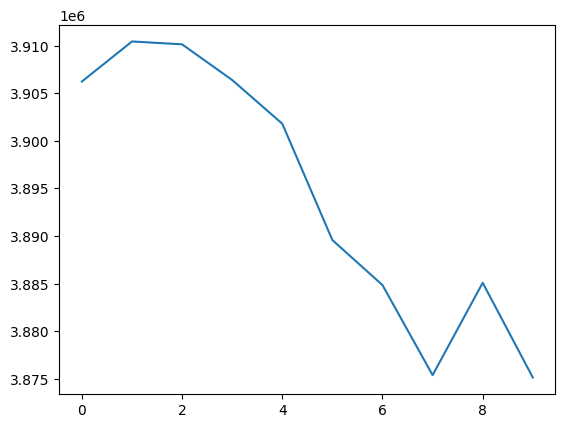

In [23]:
# plot the average counts of one of these big bins over time
plt.plot(
    timetrace_binned.coords["ql_blocks"].values, timetrace_binned.sel(x=12, y=12).values
)

In [24]:
# fig, axs = plt.subplots(len(timetrace_binned.coords['y'].values), 1, figsize=(4, 2 * len(timetrace_binned.coords['y'].values)))
# for i, y in enumerate(timetrace_binned.coords['y'].values):
#     for j, x in enumerate(timetrace_binned.coords['x'].values):
#         axs[i].plot(timetrace_binned.coords['segments'].values, normalize_array(timetrace_binned.sel(x=x, y=y).values))

## Analyse ESR data

In [25]:
%%time
ds_esr, ds_ql, ds_timetrace = widefield_get_data(folder, file, esr_normalized=True, ql_normalized=True)

CPU times: total: 15.6 ms
Wall time: 177 ms


In [26]:
data_ds = ds_esr

In [27]:
data_ds

<xarray.DataArray 'esr_normalized' (blocks: 1, y: 50, x: 50, rf: 501)> Size: 10MB
dask.array<open_dataset-esr_normalized, shape=(1, 50, 50, 501), dtype=float64, chunksize=(1, 10, 10, 501), chunktype=numpy.ndarray>
Coordinates:
  * blocks   (blocks) int64 8B 0
  * y        (y) int64 400B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
  * x        (x) int64 400B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
  * rf       (rf) float64 4kB 2.75e+09 2.75e+09 2.751e+09 ... 3e+09 3e+09

#### Optional data manipulation

In [28]:
# sum the data over the blocks
subset_ds = data_ds.sum(dim="blocks")

In [29]:
# add extra binning (this bins every 2 x 2 pixels to one new pixel)
# subset_ds = data_ds.sum(dim="blocks").coarsen(x=2, y=2, boundary="trim").mean()

In [30]:
# take only a 20 x 20 square from the data and sum the blocks
# subset_ds = data_ds.sel(x=slice(0, 9), y=slice(0, 9)).sum(dim="blocks")

In [31]:
%%time
subset_ds.persist()

CPU times: total: 0 ns
Wall time: 7.12 ms


<xarray.DataArray 'esr_normalized' (y: 50, x: 50, rf: 501)> Size: 10MB
dask.array<sum-aggregate, shape=(50, 50, 501), dtype=float64, chunksize=(10, 10, 501), chunktype=numpy.ndarray>
Coordinates:
  * y        (y) int64 400B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
  * x        (x) int64 400B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
  * rf       (rf) float64 4kB 2.75e+09 2.75e+09 2.751e+09 ... 3e+09 3e+09

#### End optional data manipulation

In [32]:
subset_ds

<xarray.DataArray 'esr_normalized' (y: 50, x: 50, rf: 501)> Size: 10MB
dask.array<sum-aggregate, shape=(50, 50, 501), dtype=float64, chunksize=(10, 10, 501), chunktype=numpy.ndarray>
Coordinates:
  * y        (y) int64 400B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
  * x        (x) int64 400B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
  * rf       (rf) float64 4kB 2.75e+09 2.75e+09 2.751e+09 ... 3e+09 3e+09

In [33]:
%%time
subset_ds.persist()

CPU times: total: 0 ns
Wall time: 8.04 ms


<xarray.DataArray 'esr_normalized' (y: 50, x: 50, rf: 501)> Size: 10MB
dask.array<sum-aggregate, shape=(50, 50, 501), dtype=float64, chunksize=(10, 10, 501), chunktype=numpy.ndarray>
Coordinates:
  * y        (y) int64 400B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
  * x        (x) int64 400B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
  * rf       (rf) float64 4kB 2.75e+09 2.75e+09 2.751e+09 ... 3e+09 3e+09

In [ ]:
%%time
fit_obj = Fit(subset_ds, nr_of_dips=8, linewidth=1.0e6, min_distance=10e6, nitrogen=15, strain=False)
fit_obj.fit_odmr_data_2d_parallel()

CPU times: total: 1min 28s
Wall time: 3min 12s


In [35]:
fit_obj.fit_result

<xarray.Dataset> Size: 1MB
Dimensions:  (x: 50, y: 50, params: 25, nr_of_minima: 8, dim: 1)
Coordinates:
  * x        (x) int64 400B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
  * y        (y) int64 400B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
Dimensions without coordinates: params, nr_of_minima, dim
Data variables:
    popt     (x, y, params) float64 500kB 9.999 -0.2354 ... 2.77e+09 1.766e+05
    perr     (x, y, params) object 500kB 0.00040697926747794807 ... 2235125.5...
    minima   (x, y, nr_of_minima) int64 160kB 417 74 305 200 ... 241 365 136 43
    redchi   (x, y, dim) float64 20kB 4.596e-05 4.464e-05 ... 5.366e-05

In [36]:
fit_obj.fit_B_field_2d_parallel()

[[[2854700625.796484, -17.89931789662646, 34.751461741451294, -8.606837329902548], [2857929596.912485, -16.086404358591103, 33.21344014965713, -6.801025948094461], [2855344877.8032837, -17.493587947246272, 34.726305133016275, -8.207882607204395], [2883351377.7168384, -18.259437326348536, 35.04769384058264, -9.106209972029662], [2882903008.440467, -17.910319941620838, 34.54709732312133, -8.78199416755422], [2881422264.407579, -16.87175581686892, 33.56841773749722, -7.750857199116783], [2882618615.4703054, -17.682602347707213, 34.359937087783806, -8.589968905027062], [2870639843.6491065, -18.55603878316303, 25.701055264258244, -8.892279728604127], [2883569970.5108356, -18.427503191720145, 35.17213137032423, -9.267975806991295], [2882938085.865099, -17.97285799027397, 34.882928910290396, -8.827793666131052], [2883548249.01013, -18.39915943027378, 35.17382731635908, -9.237864828209984], [2865278116.131267, -14.635077608127832, 29.371353462167068, -7.57408719186767], [2882615992.464788, -17

In [37]:
fit_obj.fit_B_result

<xarray.Dataset> Size: 181kB
Dimensions:    (x: 50, y: 50, params: 4)
Coordinates:
  * x          (x) int64 400B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
  * y          (y) int64 400B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
Dimensions without coordinates: params
Data variables:
    zfs_b      (x, y, params) float64 80kB 2.855e+09 -17.9 ... 34.06 -7.848
    zfs_b_err  (x, y, params) float64 80kB 0.3573 2.194e-07 ... 2.188e-07
    redchi     (x, y) float64 20kB 9.799e+12 9.562e+13 ... 4.824e+12 3.341e+13

In [38]:
plot_obj = Plot_ODMR_2D(subset_ds, fit_obj.fit_result, nitrogen=15)

(<Figure size 400x200 with 1 Axes>,
 <Axes: xlabel='freq (Hz)', ylabel='PL (a.u.)'>)

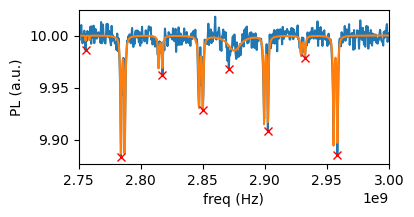

In [39]:
plot_obj.plot_specific_fit(x_val=5, y_val=5)

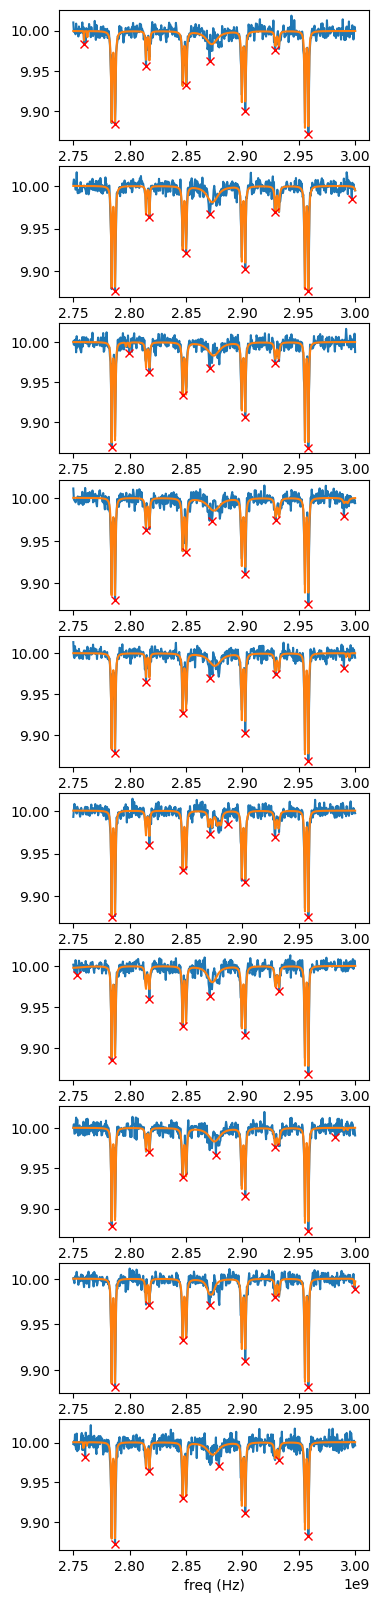

In [40]:
plot_obj.plot_first_fits(nr_of_fits=10)

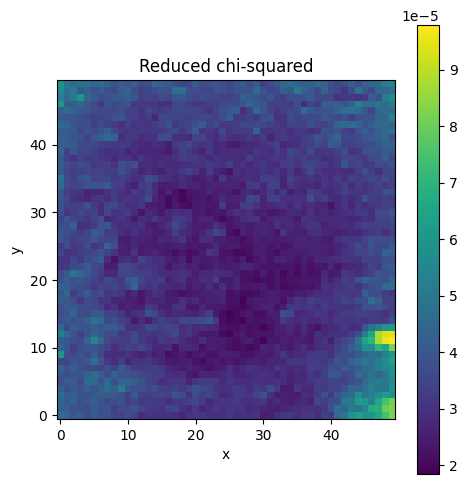

In [41]:
plot_obj.plot_redchi_2d()

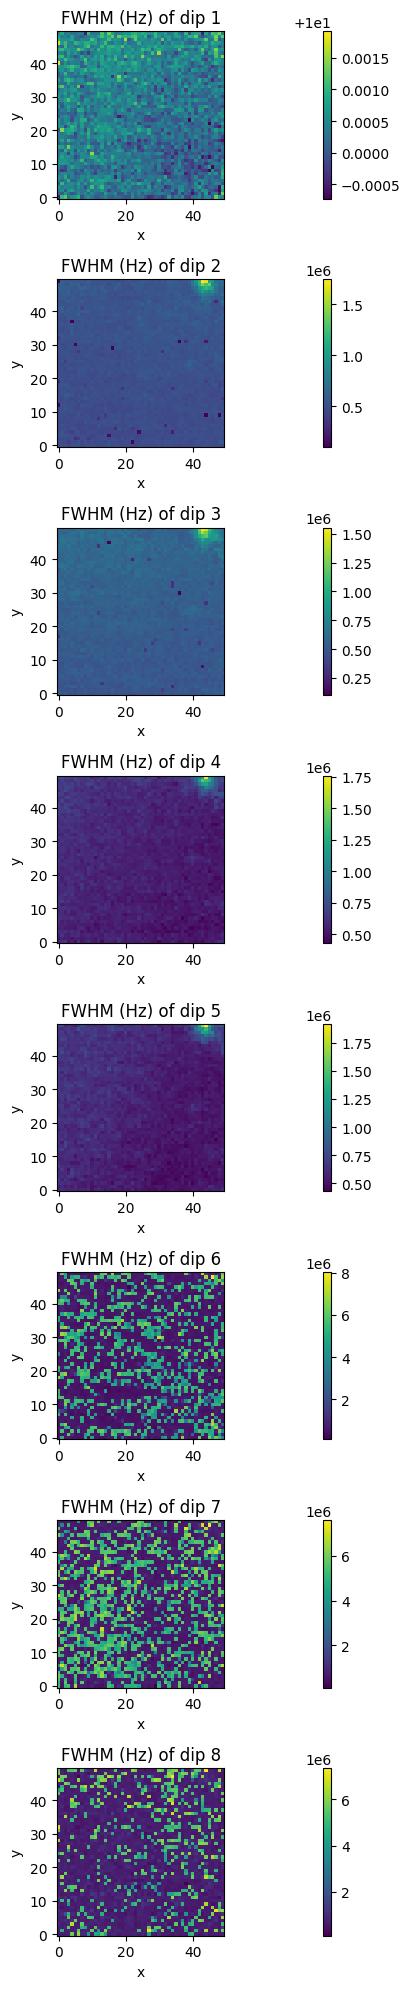

In [42]:
plot_obj.plot_fwhm_2d()

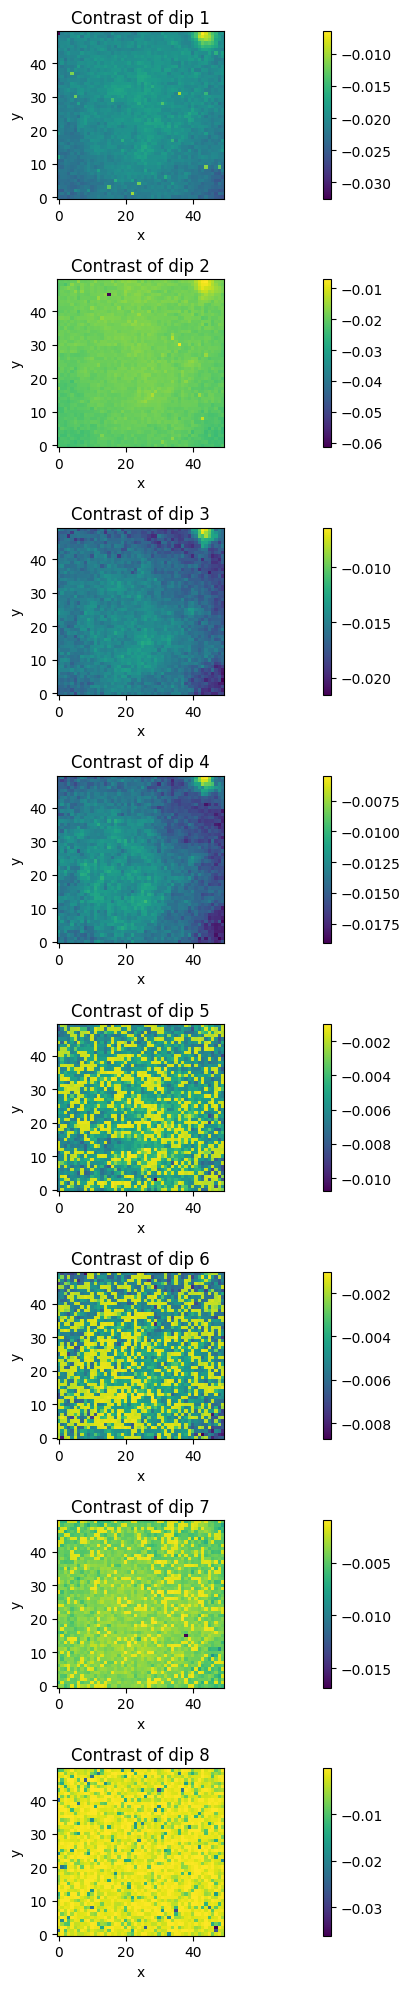

In [43]:
plot_obj.plot_contrast_2d()

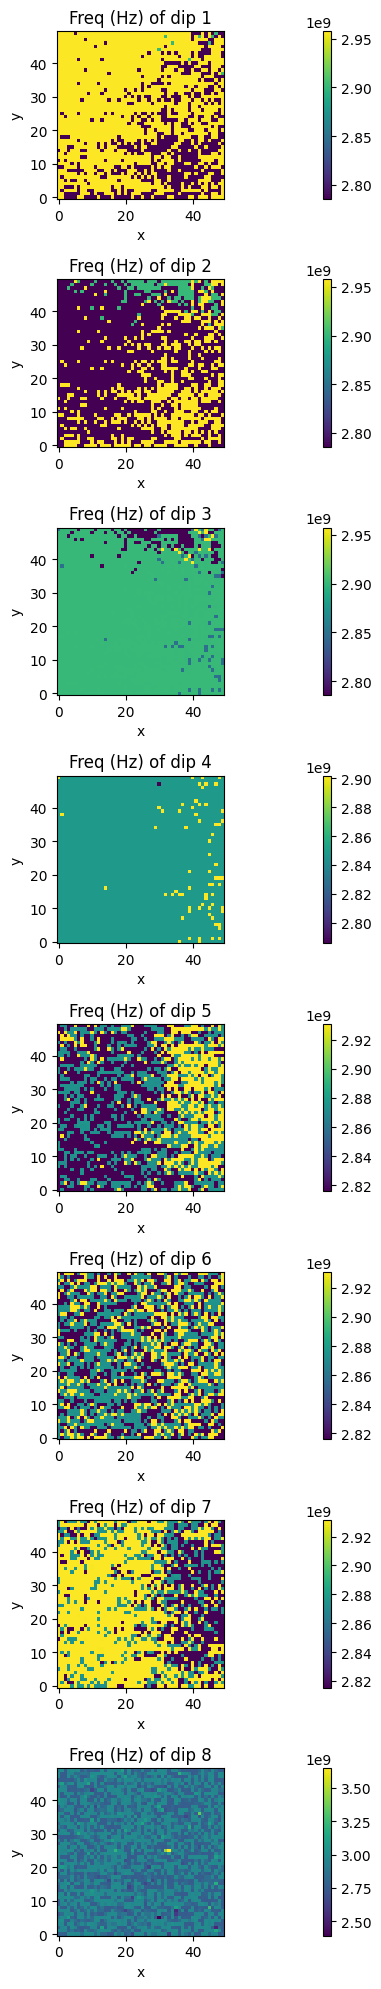

In [44]:
plot_obj.plot_freq_2d()

(<Figure size 500x400 with 2 Axes>,
 <Axes: title={'center': 'Zero-field splitting'}, xlabel='x', ylabel='y'>)

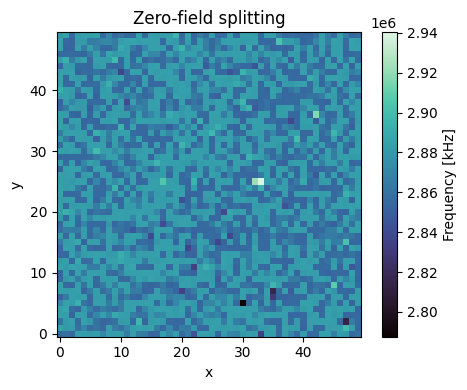

In [45]:
plot_obj = Plot_Hamiltonian_Parameters_2D(fit_obj.fit_B_result, nitrogen=15)
plot_obj.plot_zfs_2d()

(<Figure size 800x400 with 8 Axes>,
 array([<Axes: title={'center': 'Magnitude'}, xlabel='x', ylabel='y'>,
        <Axes: title={'center': '$B_x$'}, xlabel='x'>,
        <Axes: title={'center': '$B_y$'}, xlabel='x'>,
        <Axes: title={'center': '$B_z$'}, xlabel='x'>], dtype=object))

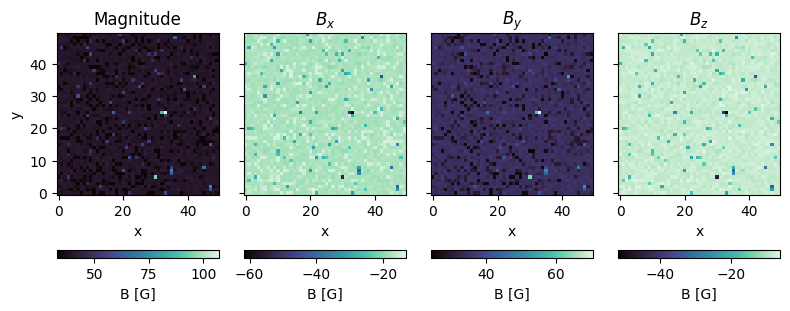

In [46]:
plot_obj.plot_B_all_comp()

In [47]:
# plot_obj.plot_strain_all_comp()

<xarray.DataArray 'redchi' (x: 50, y: 50)> Size: 20kB
array([[9.79904469e+12, 9.56248945e+13, 1.40496324e+13, ...,
        4.27946403e+13, 6.88590362e+12, 9.66269575e+13],
       [6.45648340e+13, 3.99252633e+13, 9.44377521e+12, ...,
        3.21562138e+15, 1.04657259e+13, 7.20756371e+12],
       [8.82758563e+13, 3.80414891e+13, 1.63555924e+13, ...,
        4.74331539e+15, 7.33621628e+13, 2.73777424e+13],
       ...,
       [1.93885676e+13, 1.35058993e+12, 1.32341648e+12, ...,
        3.11247923e+13, 3.97668437e+12, 1.50221954e+12],
       [1.73719811e+13, 2.83021661e+12, 1.85731675e+12, ...,
        3.15980510e+13, 4.27674128e+13, 5.79166656e+12],
       [8.79814478e+13, 5.37506388e+13, 1.50935993e+13, ...,
        6.96705837e+13, 4.82390905e+12, 3.34133091e+13]])
Coordinates:
  * x        (x) int64 400B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
  * y        (y) int64 400B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
Reduced chi squared = 6.45e+16
x = 25, y = 33
Reduced 

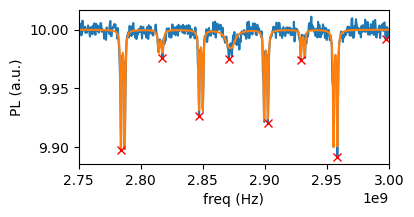

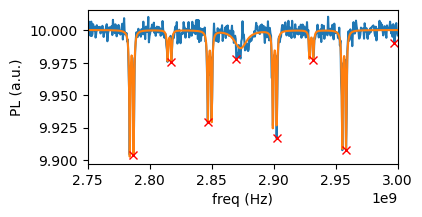

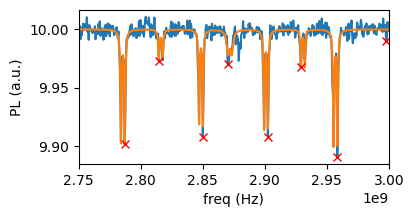

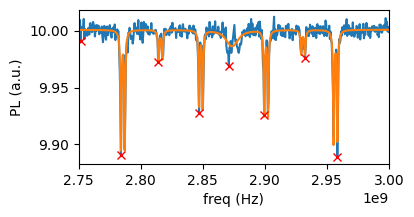

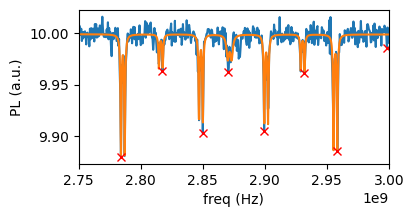

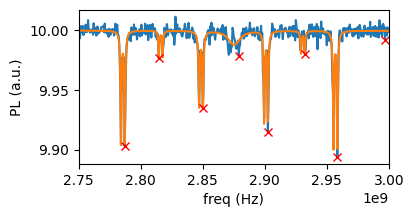

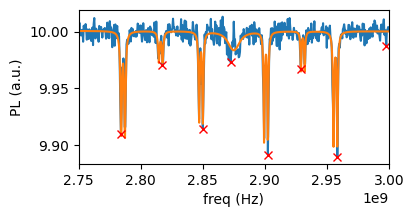

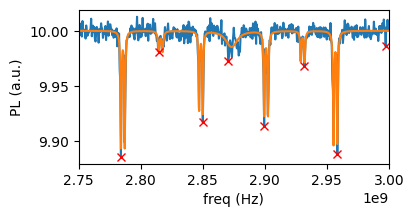

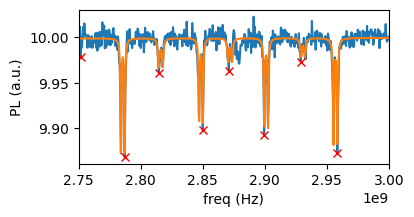

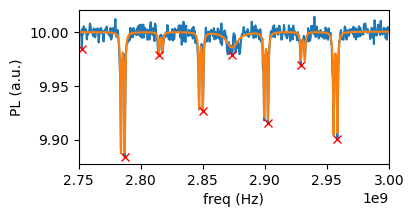

In [48]:
plot_obj.plot_failed_fits(subset_ds, fit_obj.fit_result, nr_of_fits=10)

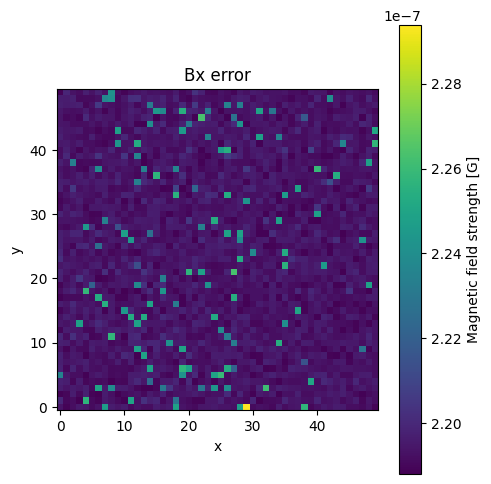

In [49]:
plot_obj.plot_B_error_2d(component="Bx")

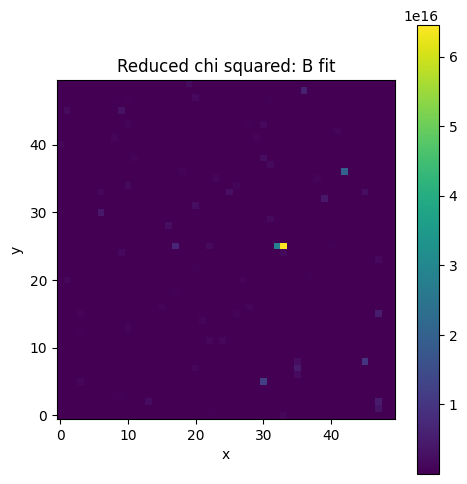

In [50]:
plot_obj.plot_redchi_2d()